In [1]:
import pandas as pd

df = pd.read_csv("musicemotions_dataset_v2.csv")
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,fileName,songID,Genre,SongName,UserID,Rating,Feeling,Gender,Nationality,Duration
0,pop/1.mp3,1,POP,Beyond Late,180,5,relaxing,M,Non-Ghana,NaN
1,pop/1.mp3,1,POP,Beyond Late,176,3,energizing,M,Ghana,NaN
2,pop/1.mp3,1,POP,Beyond Late,176,3,happy,M,Ghana,NaN
3,pop/1.mp3,1,POP,Beyond Late,176,4,joyful,M,Ghana,NaN
4,pop/1.mp3,1,POP,Beyond Late,173,5,energizing,M,Ghana,NaN


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3031 entries, 0 to 3030
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   fileName     3031 non-null   object
 1   songID       3031 non-null   int64 
 2   Genre        3031 non-null   object
 3   SongName     3031 non-null   object
 4   UserID       3031 non-null   int64 
 5   Rating       3031 non-null   int64 
 6   Feeling      3031 non-null   object
 7   Gender       3031 non-null   object
 8   Nationality  3031 non-null   object
 9   Duration     3023 non-null   object
dtypes: int64(3), object(7)
memory usage: 236.9+ KB


In [3]:
df.describe()

,songID,UserID,Rating
count,3031.000000,3031.000000,3031.000000
mean,171.632135,97.155064,3.877928
std,128.693612,49.328364,1.230368
min,1.000000,1.000000,0.000000
25%,41.000000,56.000000,3.000000
50%,141.000000,102.000000,4.000000
75%,285.000000,148.000000,5.000000
max,401.000000,181.000000,5.000000


####Data Cleaning

In [4]:
df.isnull().sum()

,0
fileName,0
songID,0
Genre,0
SongName,0
UserID,0
Rating,0
Feeling,0
Gender,0
Nationality,0
Duration,8


In [5]:
df = df[["Genre", "Rating", "Feeling"]]

In [6]:
df["Genre"] = df["Genre"].astype("category").cat.codes

In [7]:
df["Feeling"] = df["Feeling"].astype("category").cat.codes

In [8]:
X = df[["Genre", "Rating"]]
y = df["Feeling"]

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

####Something else

In [10]:
import numpy as np

# Convert to numpy
X = np.array(X_scaled)
y = np.array(y)

# Initialize weights and bias
w = np.zeros(X.shape[1])
b = 0

# Hyperparameters
learning_rate = 0.01
epochs = 1000

losses = []

In [11]:
import numpy as np

# Convert to numpy
X = np.array(X_scaled)
y = np.array(y)

# Initialize weights and bias
w = np.zeros(X.shape[1])
b = 0

# Hyperparameters
learning_rate = 0.01
epochs = 1000

losses = []

In [14]:
for i in range(epochs):

    # Predictions
    y_pred = np.dot(X, w) + b

    # Loss
    loss = np.mean((y - y_pred) ** 2)
    losses.append(loss)

    # Gradients
    dw = (-2/len(y)) * np.dot(X.T, (y - y_pred))
    db = (-2/len(y)) * np.sum(y - y_pred)

    # Update
    w = w - learning_rate * dw
    b = b - learning_rate * db

In [15]:
print(losses[:5])
print(losses[-5:])

[np.float64(27.69152095018146), np.float64(26.930814175688248), np.float64(26.20023180706874), np.float64(25.498580899292293), np.float64(24.824715748768487)]
[np.float64(8.481988416470628), np.float64(8.481988416470626), np.float64(8.481988416470626), np.float64(8.481988416470626), np.float64(8.481988416470626)]


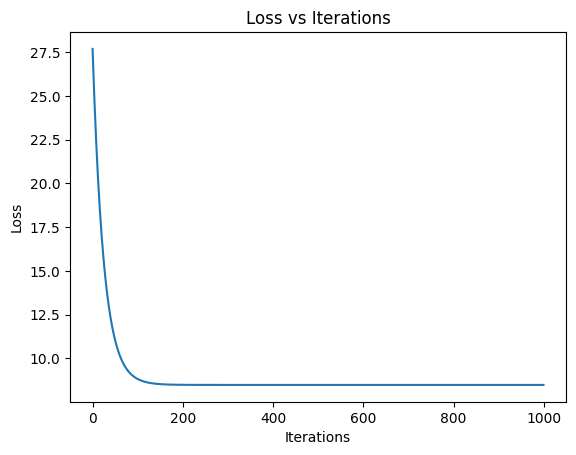

In [16]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.show()

In [13]:
print(len(losses))

0


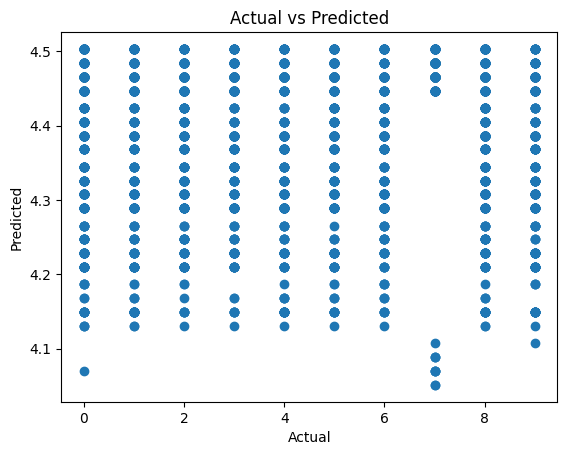

In [17]:
y_pred = np.dot(X, w) + b

import matplotlib.pyplot as plt

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()